ML Project



In [1]:
#warnings
import warnings
warnings.filterwarnings('ignore')
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Dataset
df=pd.read_csv('cirrhosis.csv') # reading dataset

In [3]:
 # dataset size
df.shape

(418, 20)

In [4]:
#data Types
df.dtypes

ID                 int64
N_Days             int64
Status            object
Drug              object
Age                int64
Sex               object
Ascites           object
Hepatomegaly      object
Spiders           object
Edema             object
Bilirubin        float64
Cholesterol      float64
Albumin          float64
Copper           float64
Alk_Phos         float64
SGOT             float64
Tryglicerides    float64
Platelets        float64
Prothrombin      float64
Stage            float64
dtype: object

In [5]:
# Columns
l=list(df.columns) #All columns
l1= list(df.select_dtypes(include=['object']).columns) # obj type columns
l2= list(df.select_dtypes(include=['number']).columns) # num type columns
print('All Columns : \n',l)
print('\nObject type Columns :\n ',l1)
print('\nFloat type Columns :\n ',l2)

All Columns : 
 ['ID', 'N_Days', 'Status', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']

Object type Columns :
  ['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']

Float type Columns :
  ['ID', 'N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']


In [6]:
# Count of unique values in object types
for i in l1:
    x=list(zip(list(df[i].unique()),list(df[i].value_counts())))
    print(f'{i}        ,{x}')

Status        ,[('D', 232), ('C', 161), ('CL', 25)]
Drug        ,[('D-penicillamine', 158), ('Placebo', 154)]
Sex        ,[('F', 374), ('M', 44)]
Ascites        ,[('Y', 288), ('N', 24)]
Hepatomegaly        ,[('Y', 160), ('N', 152)]
Spiders        ,[('Y', 222), ('N', 90)]
Edema        ,[('Y', 354), ('N', 44), ('S', 20)]


In [7]:
#info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

In [8]:
df.describe()

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,418.000000,418.000000,418.000000,418.000000,284.000000,418.000000,310.000000,312.000000,312.000000,282.000000,407.000000,416.000000,412.000000
mean,209.500000,1917.782297,18533.351675,3.220813,369.510563,3.497440,97.648387,1982.655769,122.556346,124.702128,257.024570,10.731731,3.024272
std,120.810458,1104.672992,3815.845055,4.407506,231.944545,0.424972,85.613920,2140.388824,56.699525,65.148639,98.325585,1.022000,0.882042
min,1.000000,41.000000,9598.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,105.250000,1092.750000,15644.500000,0.800000,249.500000,3.242500,41.250000,871.500000,80.600000,84.250000,188.500000,10.000000,2.000000
50%,209.500000,1730.000000,18628.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000
75%,313.750000,2613.500000,21272.500000,3.400000,400.000000,3.770000,123.000000,1980.000000,151.900000,151.000000,318.000000,11.100000,4.000000
max,418.000000,4795.000000,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


In [9]:
#checking the null cells
df.isin(['?', 'NA', 'N/A','NAN','']).any().sum()

np.int64(0)

In [10]:
# checking null values
df.isnull().sum()

ID                 0
N_Days             0
Status             0
Drug             106
Age                0
Sex                0
Ascites          106
Hepatomegaly     106
Spiders          106
Edema              0
Bilirubin          0
Cholesterol      134
Albumin            0
Copper           108
Alk_Phos         106
SGOT             106
Tryglicerides    136
Platelets         11
Prothrombin        2
Stage              6
dtype: int64

In [11]:
#handling Null Values
#if exists continue with interpolation
df.interpolate(method='linear', axis=0, limit=None, inplace=True, limit_direction=None, limit_area=None)
# methods : linear | ffill | bfill | pad
df.interpolate(method='ffill', axis=0, limit=None, inplace=True, limit_direction=None, limit_area=None)

In [12]:
df.duplicated().sum() # count of dublicate values

np.int64(0)

In [13]:
negatives = (df.select_dtypes(include='number') < 0).sum() # count of negative values
print(negatives)

ID               0
N_Days           0
Age              0
Bilirubin        0
Cholesterol      0
Albumin          0
Copper           0
Alk_Phos         0
SGOT             0
Tryglicerides    0
Platelets        0
Prothrombin      0
Stage            0
dtype: int64


In [14]:
df.isnull().sum() # null count

ID               0
N_Days           0
Status           0
Drug             0
Age              0
Sex              0
Ascites          0
Hepatomegaly     0
Spiders          0
Edema            0
Bilirubin        0
Cholesterol      0
Albumin          0
Copper           0
Alk_Phos         0
SGOT             0
Tryglicerides    0
Platelets        0
Prothrombin      0
Stage            0
dtype: int64

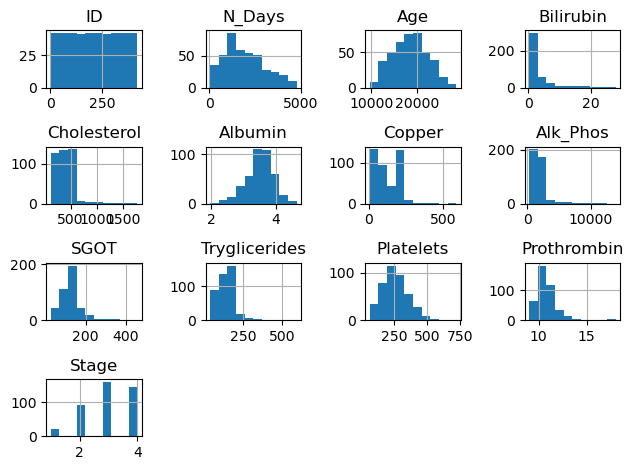

In [15]:
df.hist()
plt.tight_layout()
plt.show()

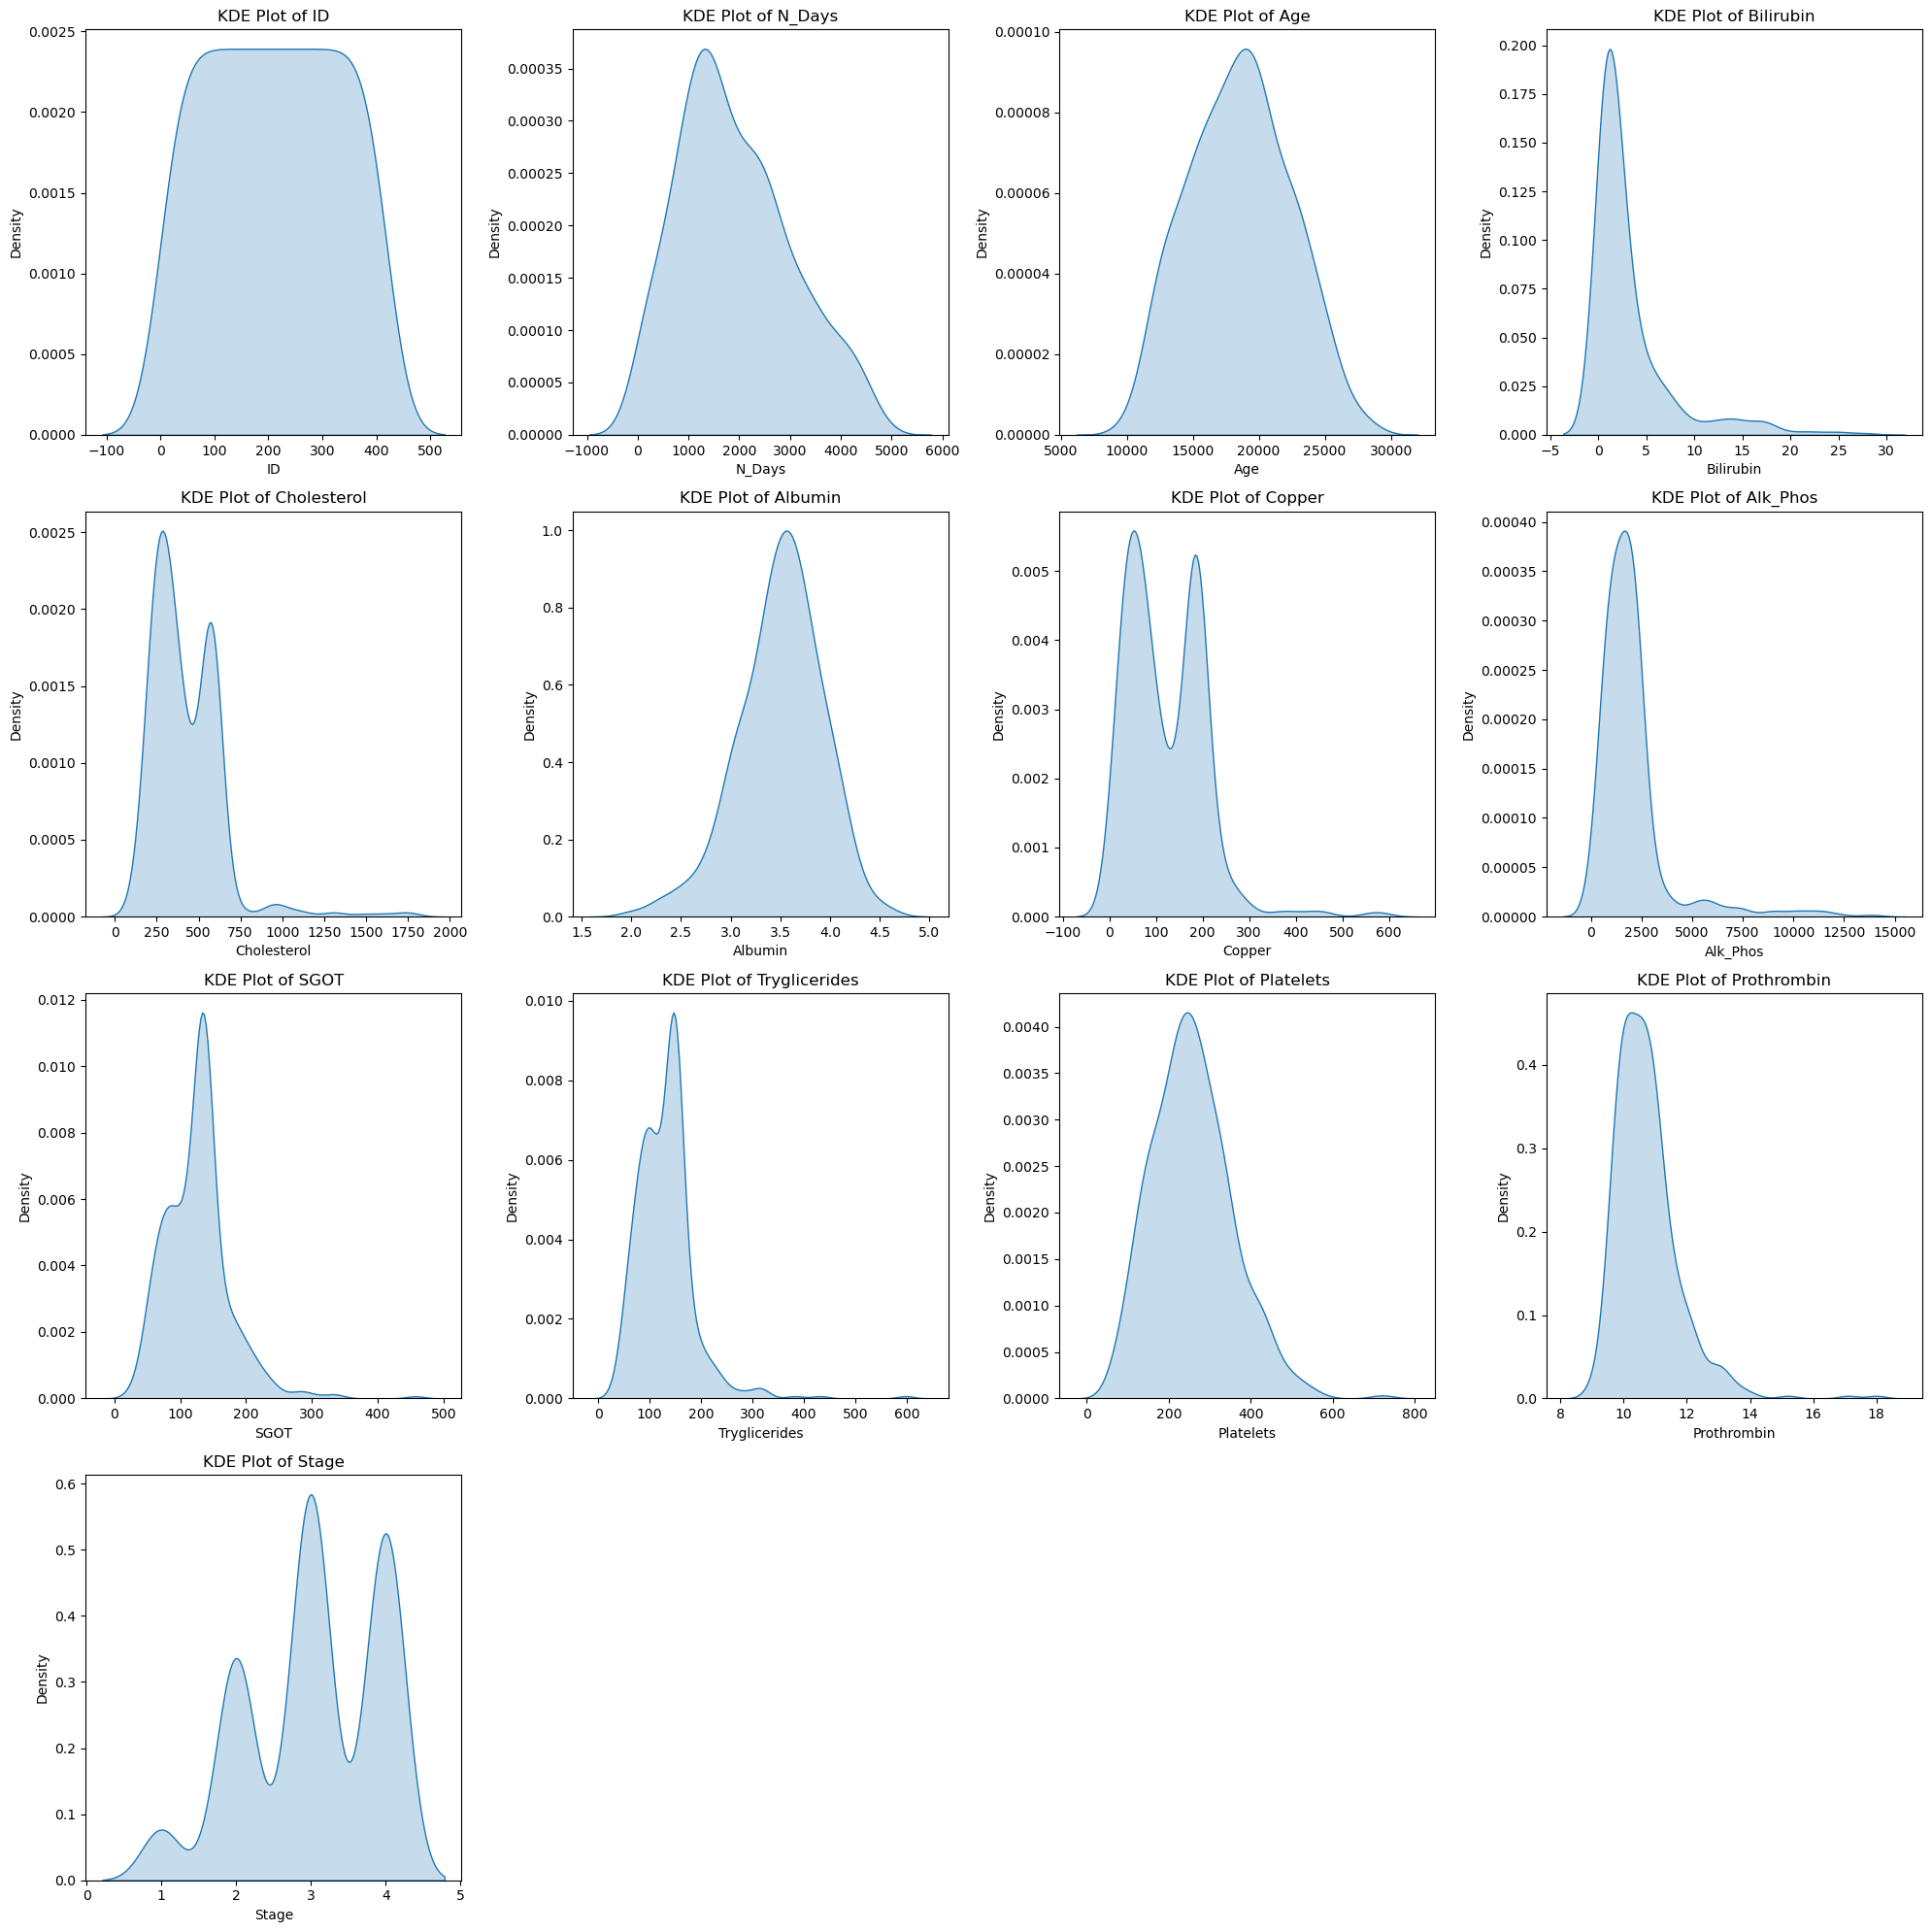

In [16]:
num_cols = len(l2)
num_rows = (num_cols + 3) // 4  # Displaying 4 plots per row

fig, axes = plt.subplots(num_rows, 4, figsize=(20, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(l2):
    sns.kdeplot(df[col], fill=True, ax=axes[i])
    axes[i].set_title(f'KDE Plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

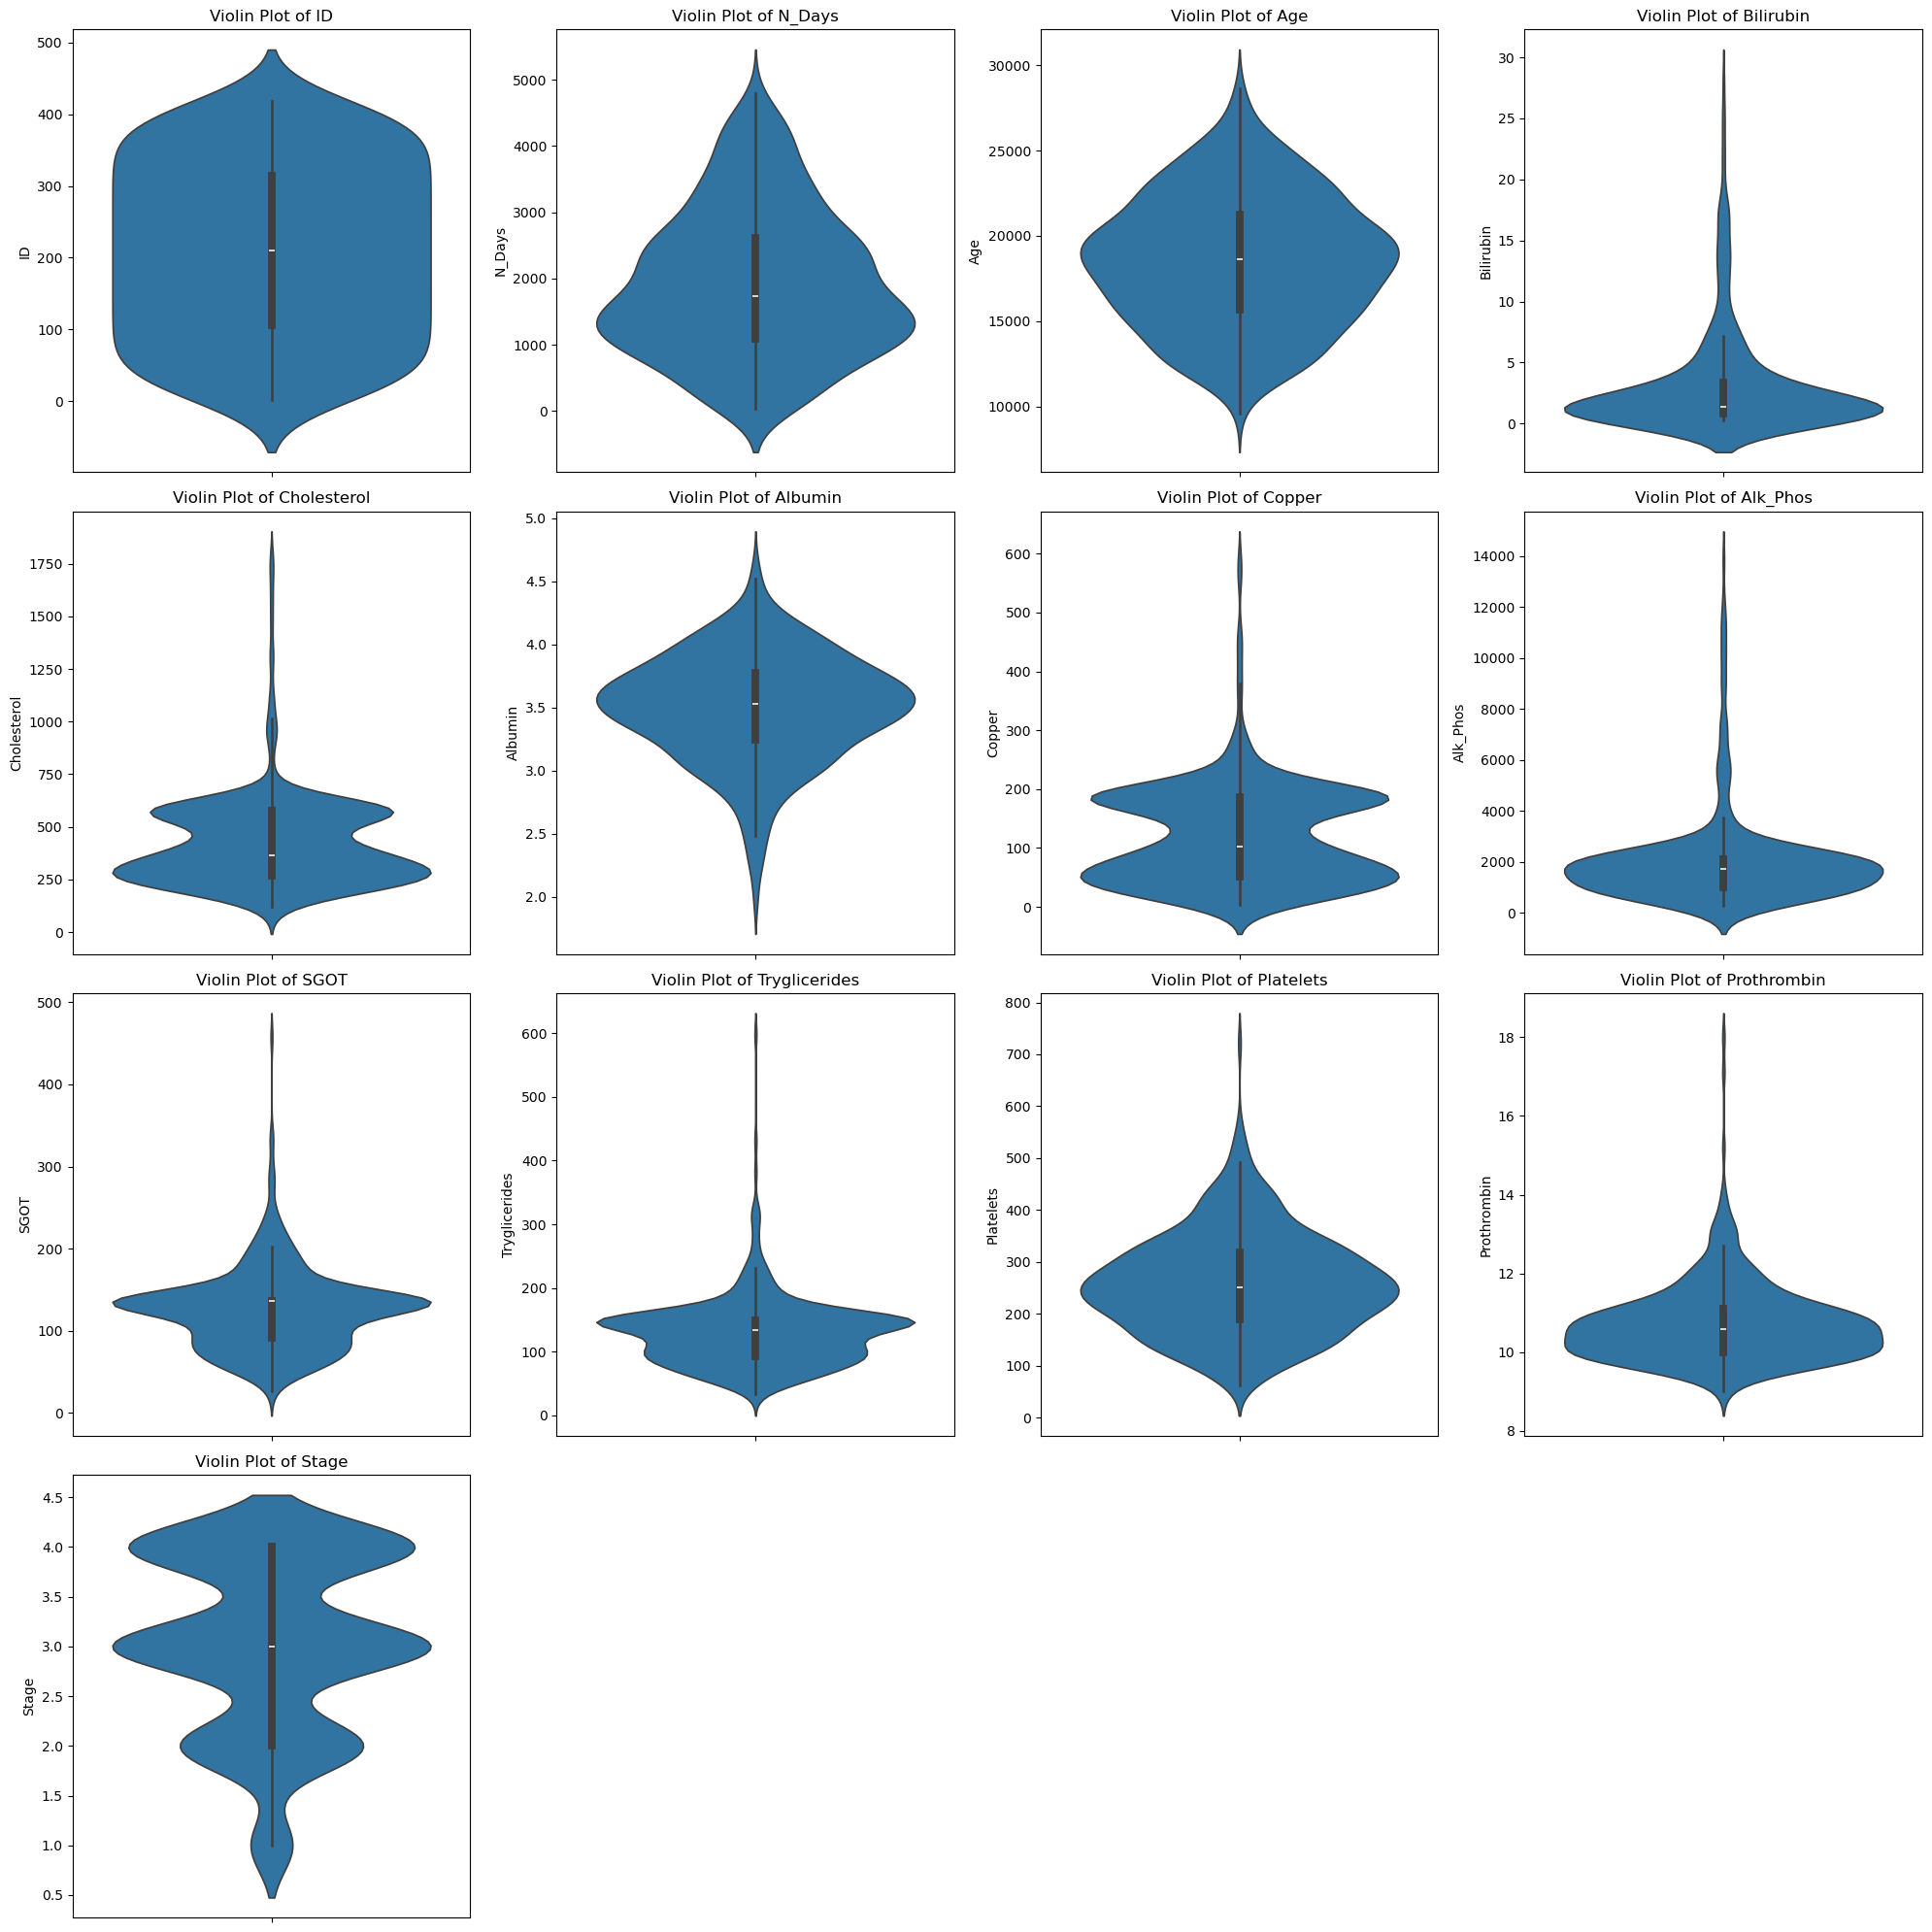

In [17]:
num_cols_violin = len(l2)
num_rows_violin = (num_cols_violin + 3) // 4  # Displaying 4 plots per row

fig_violin, axes_violin = plt.subplots(num_rows_violin, 4, figsize=(20, 5 * num_rows_violin))
axes_violin = axes_violin.flatten()

for i, col in enumerate(l2):
    sns.violinplot(y=df[col], ax=axes_violin[i])
    axes_violin[i].set_title(f'Violin Plot of {col}')
    axes_violin[i].set_ylabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes_violin)):
    fig_violin.delaxes(axes_violin[j])

plt.tight_layout()
plt.show()

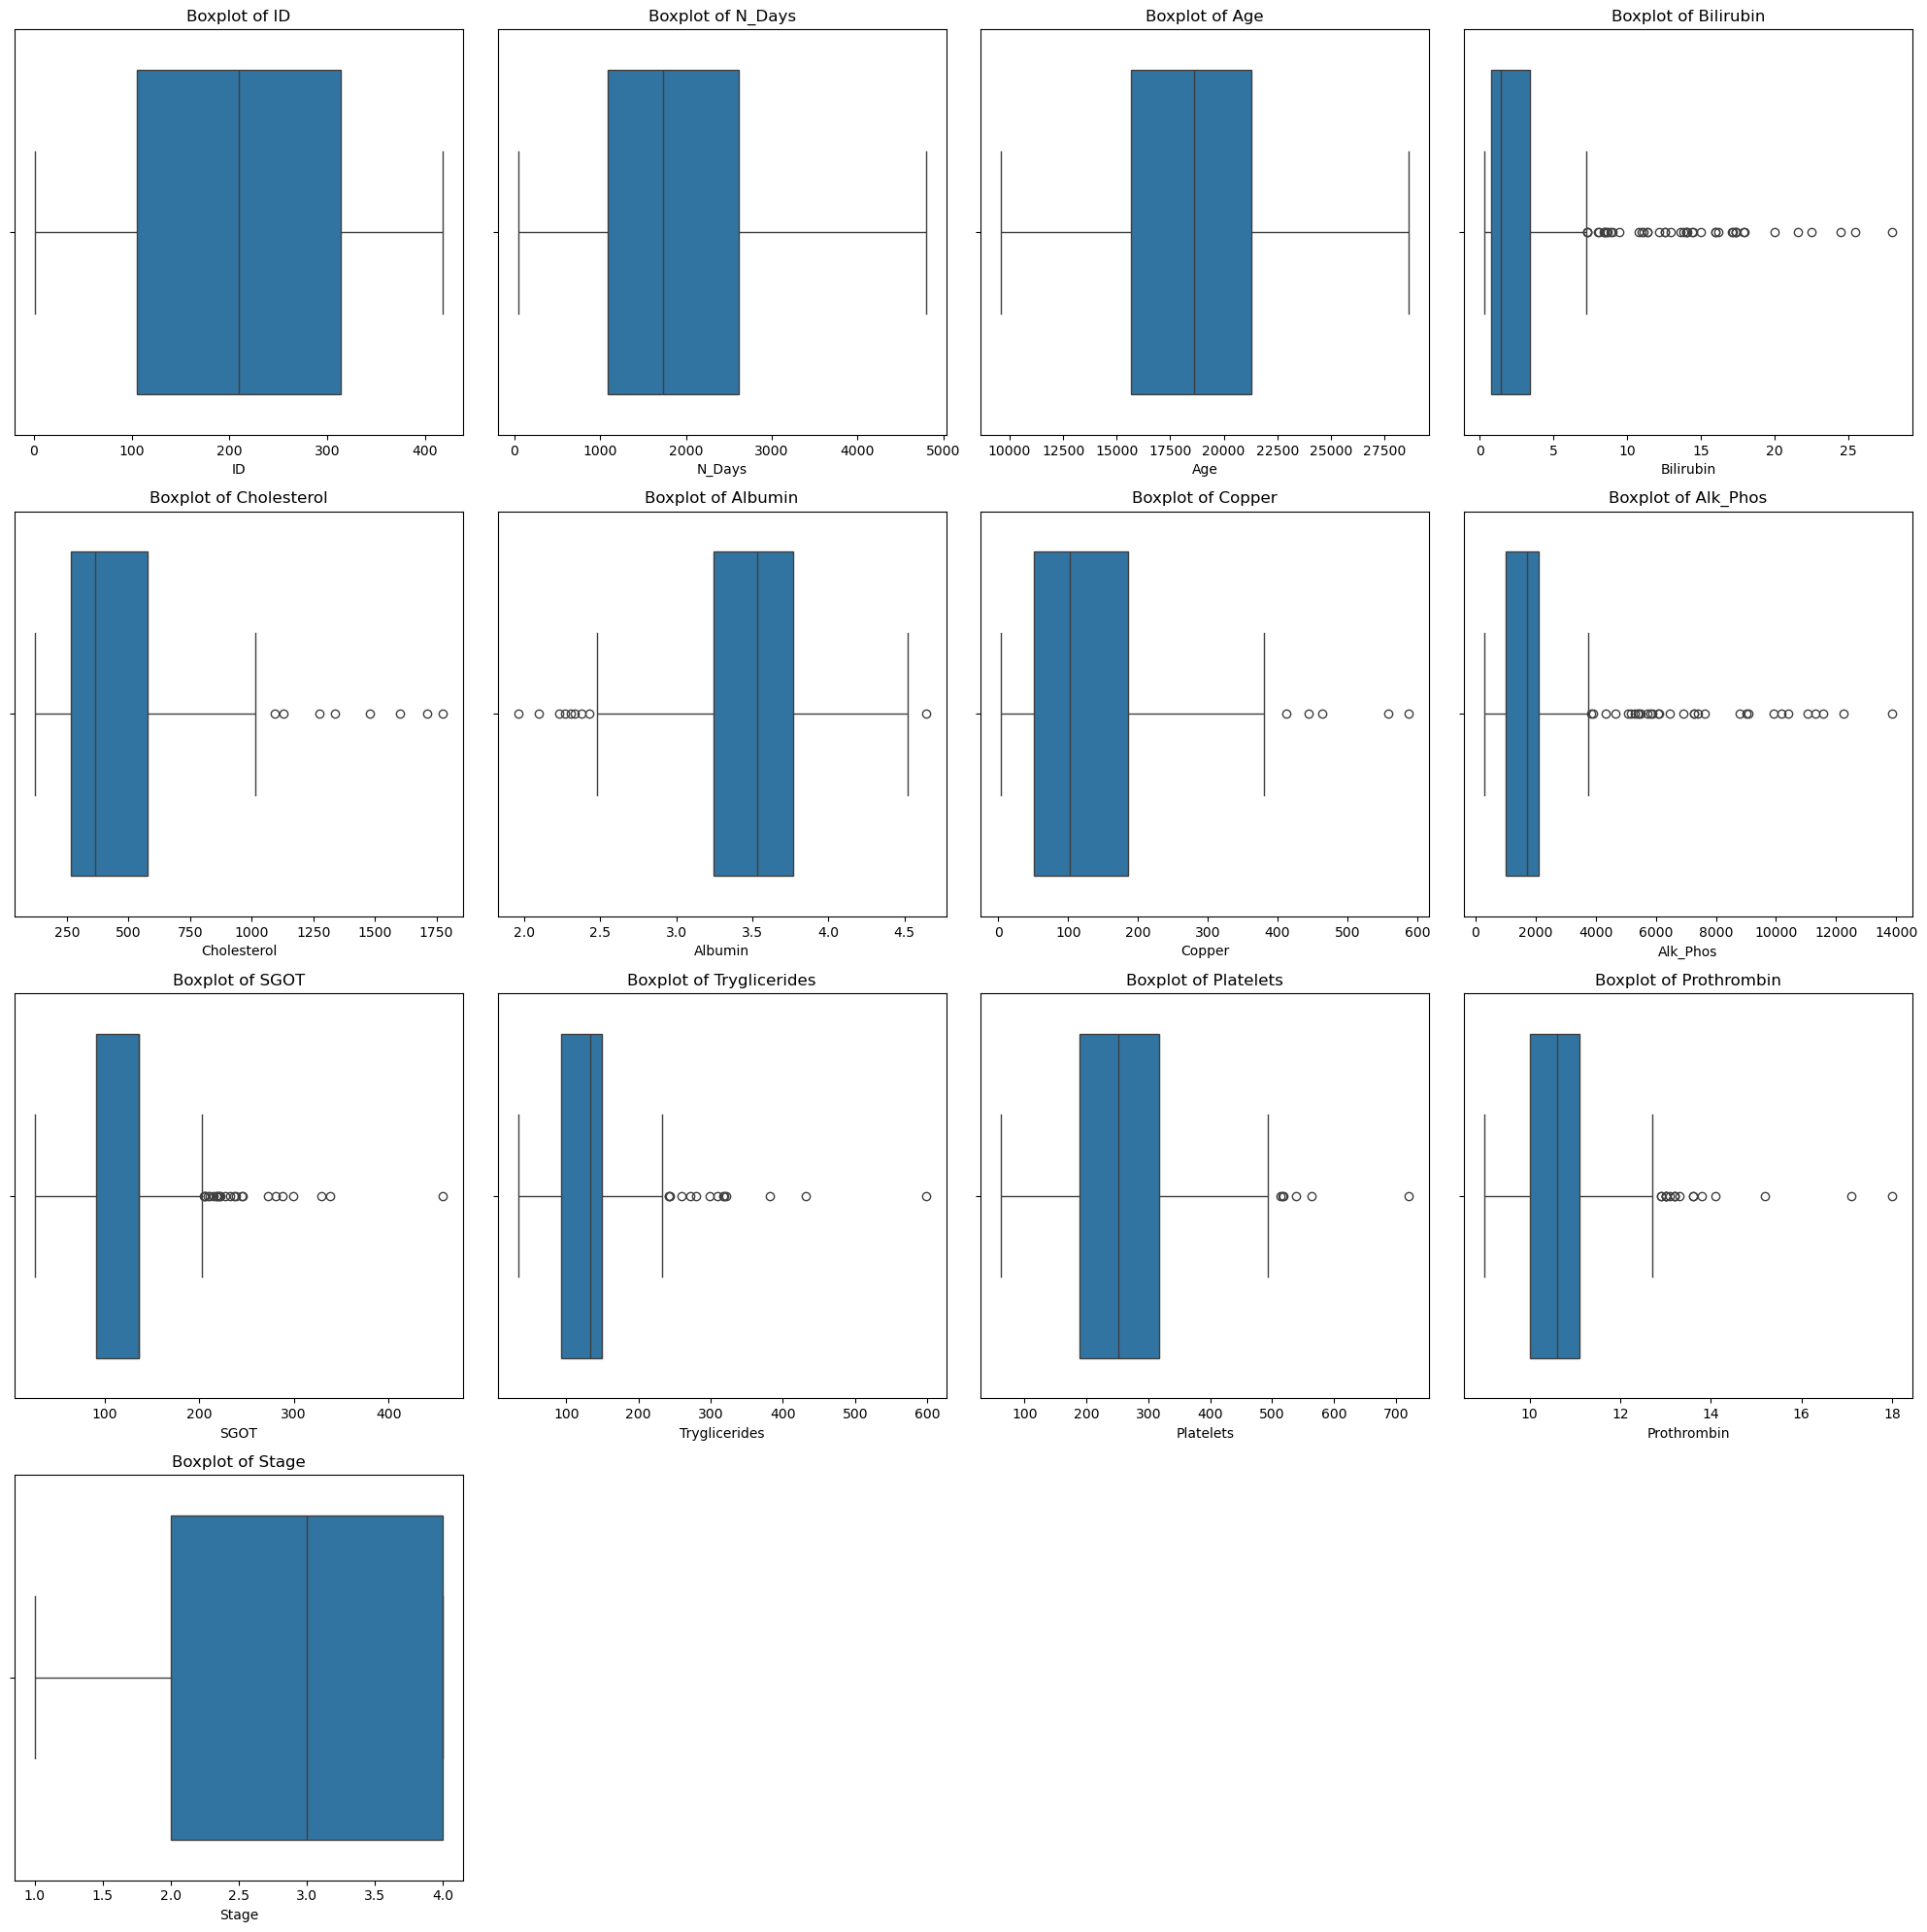

In [18]:
num_cols_boxplot = len(l2)
num_rows_boxplot = (num_cols_boxplot + 3) // 4  # Displaying 4 plots per row

fig_boxplot, axes_boxplot = plt.subplots(num_rows_boxplot, 4, figsize=(20, 5 * num_rows_boxplot))
axes_boxplot = axes_boxplot.flatten()

for i, col in enumerate(l2):
    sns.boxplot(x=df[col], ax=axes_boxplot[i])
    axes_boxplot[i].set_title(f'Boxplot of {col}')
    axes_boxplot[i].set_xlabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes_boxplot)):
    fig_boxplot.delaxes(axes_boxplot[j])

plt.tight_layout()
plt.show()

columns that have outliers are:
Bilirubin,
Cholesterol,
Albumin,
Copper,
Alk_Phos,
SGOT,
Tryglicerides,
Platelets,
Prothrombin.

In [19]:
outliers_columns=['Bilirubin','Cholesterol','Albumin','Copper','Alk_Phos','SGOT','Tryglicerides','Platelets','Prothrombin']

In [20]:
#handling outliers using IQR capping
for col in df[outliers_columns]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower_bound, upper_bound)

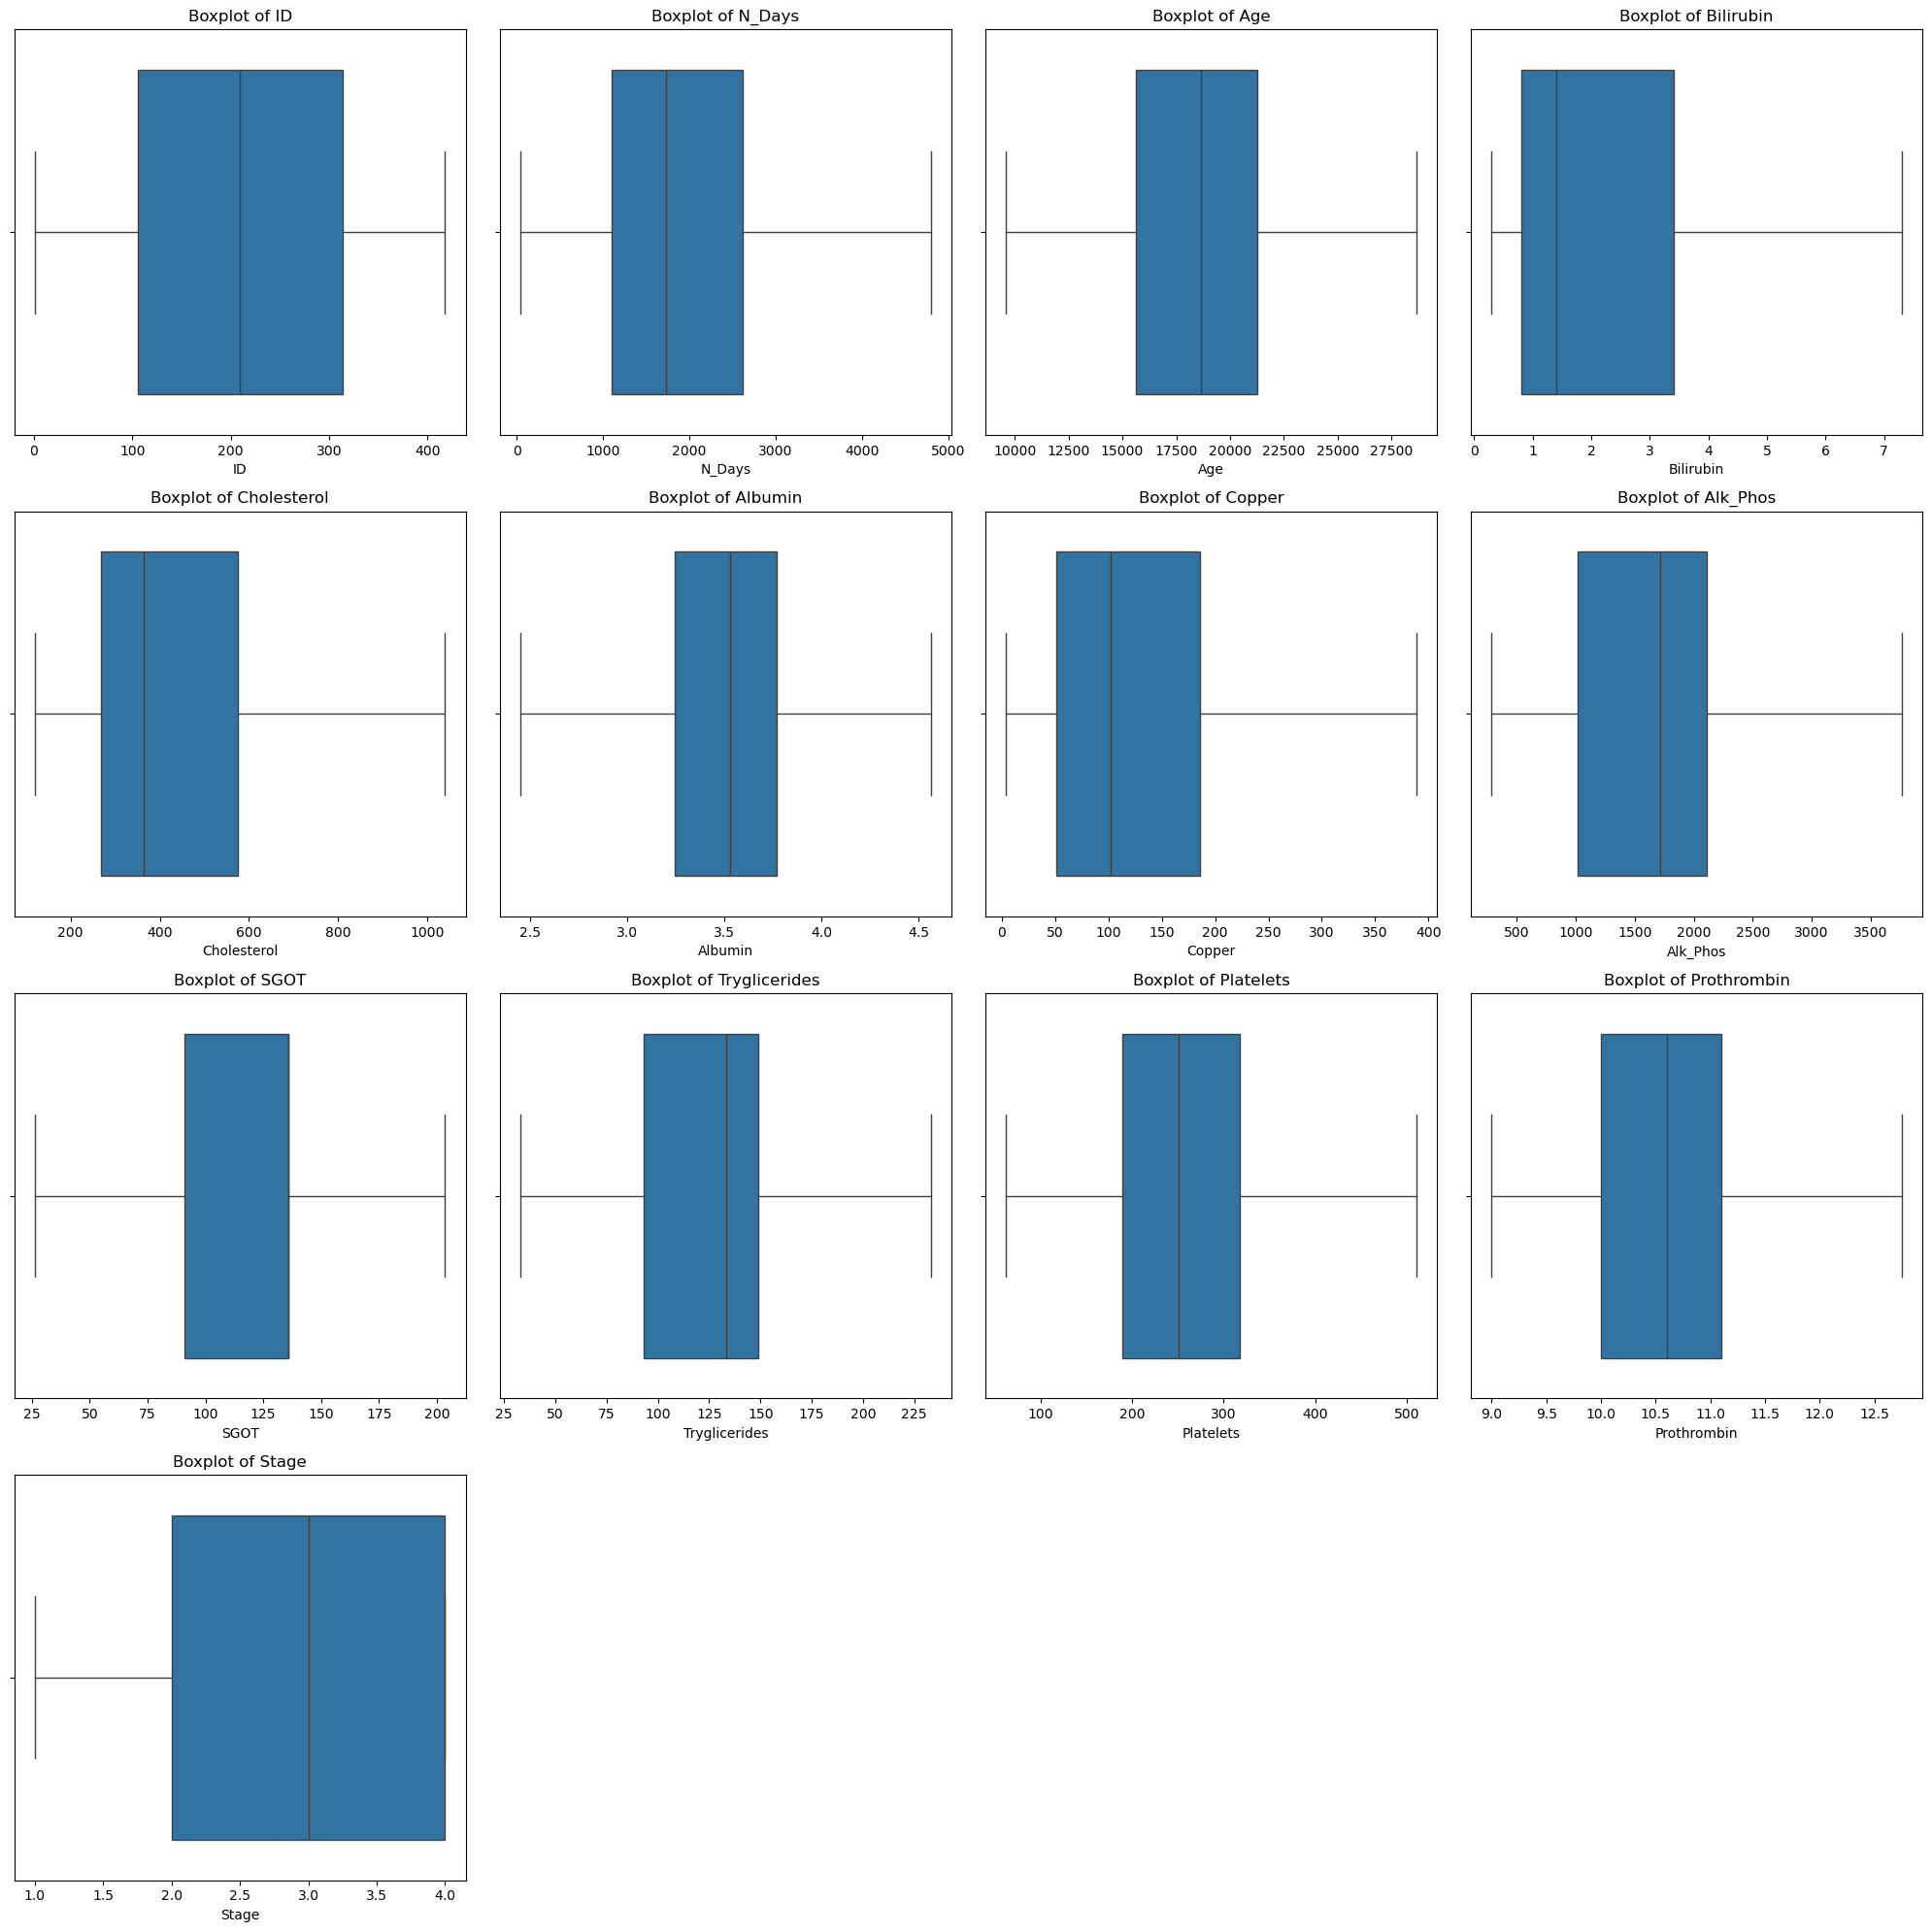

In [21]:
num_cols_boxplot = len(l2)
num_rows_boxplot = (num_cols_boxplot + 3) // 4  # Displaying 4 plots per row

fig_boxplot, axes_boxplot = plt.subplots(num_rows_boxplot, 4, figsize=(20, 5 * num_rows_boxplot))
axes_boxplot = axes_boxplot.flatten()

for i, col in enumerate(l2):
    sns.boxplot(x=df[col], ax=axes_boxplot[i])
    axes_boxplot[i].set_title(f'Boxplot of {col}')
    axes_boxplot[i].set_xlabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes_boxplot)):
    fig_boxplot.delaxes(axes_boxplot[j])

plt.tight_layout()
plt.show()

In [22]:
df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,7.3,261.0,2.60,156.0,1718.000,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,3763.125,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.000,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,3763.125,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.000,113.15,72.0,136.0,10.9,3.0


In [23]:
df['Age'] = df['Age'] / 365

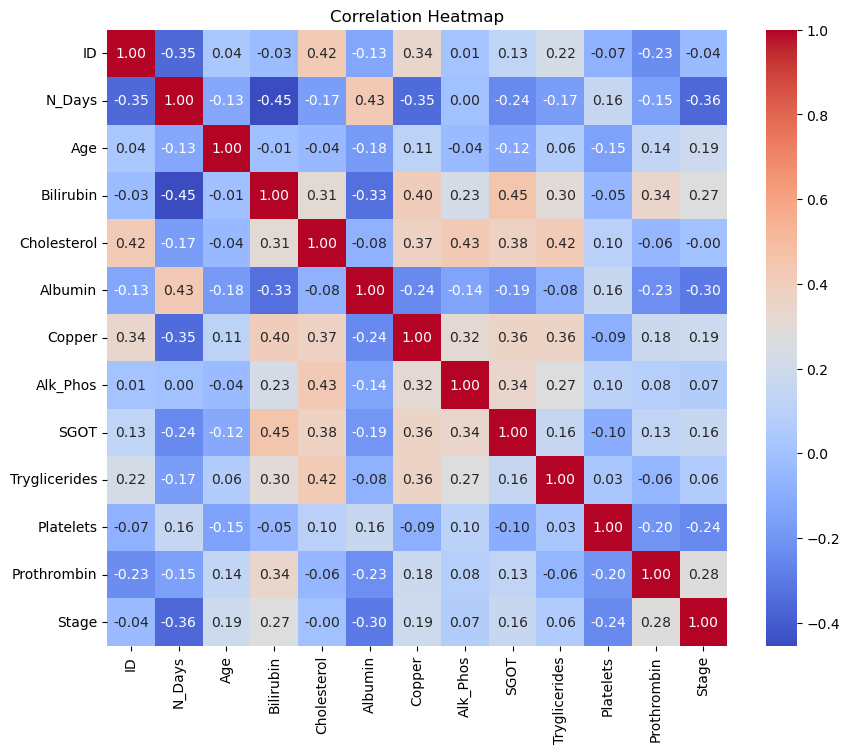

In [24]:
#Co-relation heat map
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [25]:
encoding_columns=['Status','Drug','Sex','Ascites','Hepatomegaly','Spiders','Edema']

In [26]:
#label
from sklearn.preprocessing import LabelEncoder
for i in encoding_columns:
    le = LabelEncoder()
    df[i] = le.fit_transform(df[i])

In [27]:
df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,2,0,58.805479,0,1,1,1,2,7.3,261.0,2.60,156.0,1718.000,137.95,172.0,190.0,12.2,4.0
1,2,4500,0,0,56.484932,0,0,1,1,0,1.1,302.0,4.14,54.0,3763.125,113.52,88.0,221.0,10.6,3.0
2,3,1012,2,0,70.120548,1,0,0,0,1,1.4,176.0,3.48,210.0,516.000,96.10,55.0,151.0,12.0,4.0
3,4,1925,2,0,54.778082,0,0,1,1,1,1.8,244.0,2.54,64.0,3763.125,60.63,92.0,183.0,10.3,4.0
4,5,1504,1,1,38.131507,0,0,1,1,0,3.4,279.0,3.53,143.0,671.000,113.15,72.0,136.0,10.9,3.0


In [28]:
df2=df
y=df2['Stage']
X=df2.drop('Stage',axis=1)

In [29]:
X.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin
0,1,400,2,0,58.805479,0,1,1,1,2,7.3,261.0,2.60,156.0,1718.000,137.95,172.0,190.0,12.2
1,2,4500,0,0,56.484932,0,0,1,1,0,1.1,302.0,4.14,54.0,3763.125,113.52,88.0,221.0,10.6
2,3,1012,2,0,70.120548,1,0,0,0,1,1.4,176.0,3.48,210.0,516.000,96.10,55.0,151.0,12.0
3,4,1925,2,0,54.778082,0,0,1,1,1,1.8,244.0,2.54,64.0,3763.125,60.63,92.0,183.0,10.3
4,5,1504,1,1,38.131507,0,0,1,1,0,3.4,279.0,3.53,143.0,671.000,113.15,72.0,136.0,10.9


In [30]:
y.head()

0    4.0
1    3.0
2    4.0
3    4.0
4    3.0
Name: Stage, dtype: float64

In [31]:
print(y.unique())
print(f'Count of unique values: {y.unique().shape[0]}')
print('\nIndividual unique value counts:')
print(y.value_counts())

[4.  3.  2.  1.  2.5]
Count of unique values: 5

Individual unique value counts:
Stage
3.0    160
4.0    144
2.0     92
1.0     21
2.5      1
Name: count, dtype: int64


In [32]:
y = y.astype(int)

In [33]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [34]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X, y)

print('Resampled class distribution:')
print(y_resampled.value_counts())

Resampled class distribution:
Stage
4    160
3    160
2    160
1    160
Name: count, dtype: int64


In [35]:
from sklearn.model_selection import train_test_split
#splitting dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=19) # train-80 ,test-20

In [36]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(334, 19)
(334,)
(84, 19)
(84,)


Model creation

Classification models :Logistic Regression, Decision Trees, Random Forests, Support Vector Machines (SVM), K-Nearest Neighbors (KNN), and Naive Bayes

Logistic Regression

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, max_iter=200) # Increased max_iter for convergence

# Train the model
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")

# Print classification report
print("\nClassification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_log_reg))

Logistic Regression Accuracy: 0.4643

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.38      0.19      0.25        27
           3       0.42      0.58      0.49        31
           4       0.59      0.62      0.60        26

    accuracy                           0.46        84
   macro avg       0.35      0.35      0.34        84
weighted avg       0.46      0.46      0.45        84



In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define the parameter grid for Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'], # 'liblinear' is good for small datasets, 'lbfgs' for larger ones
    'max_iter': [100, 200, 300]
}

# Initialize Logistic Regression model
log_reg = LogisticRegression(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    scoring='accuracy', # Optimize for accuracy
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Get the best model
best_log_reg_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred_tuned_log_reg = best_log_reg_model.predict(X_test)

# Evaluate the best model
accuracy_tuned_log_reg = accuracy_score(y_test, y_pred_tuned_log_reg)
print(f"Hypertuned Logistic Regression Test Accuracy: {accuracy_tuned_log_reg:.4f}")

# Print classification report
print("\nClassification Report for Hypertuned Logistic Regression:")
print(classification_report(y_test, y_pred_tuned_log_reg))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'C': 0.1, 'max_iter': 100, 'solver': 'liblinear'}
Best cross-validation accuracy: 0.4848
Hypertuned Logistic Regression Test Accuracy: 0.5000

Classification Report for Hypertuned Logistic Regression:
              precision    recall  f1-score   support

           2       0.71      0.19      0.29        27
           3       0.45      0.65      0.53        31
           4       0.52      0.65      0.58        26

    accuracy                           0.50        84
   macro avg       0.56      0.49      0.47        84
weighted avg       0.56      0.50      0.47        84



Decision Trees

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test)

# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")

# Print classification report
print("\nClassification Report for Decision Tree:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.4048

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.38      0.30      0.33        27
           3       0.38      0.42      0.40        31
           4       0.52      0.50      0.51        26

    accuracy                           0.40        84
   macro avg       0.32      0.30      0.31        84
weighted avg       0.42      0.40      0.41        84



In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Define the parameter grid for Decision Tree
param_grid_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 5, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Initialize Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid_dt,
    cv=5, # 5-fold cross-validation
    scoring='accuracy', # Optimize for accuracy
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_dt.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters for Decision Tree: {grid_search_dt.best_params_}")
print(f"Best cross-validation accuracy for Decision Tree: {grid_search_dt.best_score_:.4f}")

# Get the best Decision Tree model
best_dt_model = grid_search_dt.best_estimator_

# Make predictions on the test set using the best model
y_pred_tuned_dt = best_dt_model.predict(X_test)

# Evaluate the best model
accuracy_tuned_dt = accuracy_score(y_test, y_pred_tuned_dt)
print(f"Hypertuned Decision Tree Test Accuracy: {accuracy_tuned_dt:.4f}")

# Print classification report
print("\nClassification Report for Hypertuned Decision Tree:")
print(classification_report(y_test, y_pred_tuned_dt))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters for Decision Tree: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation accuracy for Decision Tree: 0.4371
Hypertuned Decision Tree Test Accuracy: 0.3929

Classification Report for Hypertuned Decision Tree:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.29      0.22      0.25        27
           3       0.37      0.45      0.41        31
           4       0.54      0.50      0.52        26

    accuracy                           0.39        84
   macro avg       0.30      0.29      0.29        84
weighted avg       0.40      0.39      0.39        84



Random Forests

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Random Forest Classifier
random_forest_model = RandomForestClassifier(random_state=42)

# Train the model
random_forest_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

# Print classification report
print("\nClassification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.5000

Classification Report for Random Forest:
              precision    recall  f1-score   support

           2       0.50      0.22      0.31        27
           3       0.44      0.61      0.51        31
           4       0.59      0.65      0.62        26

    accuracy                           0.50        84
   macro avg       0.51      0.50      0.48        84
weighted avg       0.51      0.50      0.48        84



In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Define the parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200], # Number of trees in the forest
    'max_depth': [None, 10, 20, 30], # Maximum depth of the tree
    'min_samples_leaf': [1, 2, 4], # Minimum number of samples required to be at a leaf node
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'criterion': ['gini', 'entropy'] # Function to measure the quality of a split
}

# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5, # 5-fold cross-validation
    scoring='accuracy', # Optimize for accuracy
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters for Random Forest: {grid_search_rf.best_params_}")
print(f"Best cross-validation accuracy for Random Forest: {grid_search_rf.best_score_:.4f}")

# Get the best Random Forest model
best_rf_model = grid_search_rf.best_estimator_

# Make predictions on the test set using the best model
y_pred_tuned_rf = best_rf_model.predict(X_test)

# Evaluate the best model
accuracy_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)
print(f"Hypertuned Random Forest Test Accuracy: {accuracy_tuned_rf:.4f}")

# Print classification report
print("\nClassification Report for Hypertuned Random Forest:")
print(classification_report(y_test, y_pred_tuned_rf))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters for Random Forest: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validation accuracy for Random Forest: 0.5208
Hypertuned Random Forest Test Accuracy: 0.5119

Classification Report for Hypertuned Random Forest:
              precision    recall  f1-score   support

           2       0.56      0.19      0.28        27
           3       0.45      0.58      0.51        31
           4       0.57      0.77      0.66        26

    accuracy                           0.51        84
   macro avg       0.53      0.51      0.48        84
weighted avg       0.52      0.51      0.48        84



Support Vector Machines (SVM)

In [63]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [64]:
'''

# Initialize the Support Vector Machine Classifier
# Using a linear kernel initially for simplicity and speed. Consider 'rbf' for more complex decision boundaries.
# The 'gamma' and 'C' parameters are crucial for SVM performance.
svm_model = SVC(kernel='linear', random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Support Vector Machine Accuracy: {accuracy_svm:.4f}")

# Print classification report
print("\nClassification Report for Support Vector Machine:")
print(classification_report(y_test, y_pred_svm))
'''

'\n\n# Initialize the Support Vector Machine Classifier\n# Using a linear kernel initially for simplicity and speed. Consider \'rbf\' for more complex decision boundaries.\n# The \'gamma\' and \'C\' parameters are crucial for SVM performance.\nsvm_model = SVC(kernel=\'linear\', random_state=42)\n\n# Train the model\nsvm_model.fit(X_train, y_train)\n\n# Make predictions on the test set\ny_pred_svm = svm_model.predict(X_test)\n\n# Evaluate the model\naccuracy_svm = accuracy_score(y_test, y_pred_svm)\nprint(f"Support Vector Machine Accuracy: {accuracy_svm:.4f}")\n\n# Print classification report\nprint("\nClassification Report for Support Vector Machine:")\nprint(classification_report(y_test, y_pred_svm))\n'

In [44]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# It's good practice to scale data for SVMs
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42))
])

# Define the parameter grid for SVM
param_grid_svm = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.1, 1],
    'svm__kernel': ['rbf', 'linear'] # 'rbf' is often a good default, 'linear' for linear boundaries
}

# Initialize GridSearchCV
grid_search_svm = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid_svm,
    cv=5, # 5-fold cross-validation
    scoring='accuracy', # Optimize for accuracy
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_svm.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters for SVM: {grid_search_svm.best_params_}")
print(f"Best cross-validation accuracy for SVM: {grid_search_svm.best_score_:.4f}")

# Get the best SVM model
best_svm_model = grid_search_svm.best_estimator_

# Make predictions on the test set using the best model
y_pred_tuned_svm = best_svm_model.predict(X_test)

# Evaluate the best model
accuracy_tuned_svm = accuracy_score(y_test, y_pred_tuned_svm)
print(f"Hypertuned Support Vector Machine Test Accuracy: {accuracy_tuned_svm:.4f}")

# Print classification report
print("\nClassification Report for Hypertuned Support Vector Machine:")
print(classification_report(y_test, y_pred_tuned_svm))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters for SVM: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best cross-validation accuracy for SVM: 0.5090
Hypertuned Support Vector Machine Test Accuracy: 0.5238

Classification Report for Hypertuned Support Vector Machine:
              precision    recall  f1-score   support

           2       0.33      0.04      0.07        27
           3       0.46      0.77      0.58        31
           4       0.66      0.73      0.69        26

    accuracy                           0.52        84
   macro avg       0.48      0.51      0.45        84
weighted avg       0.48      0.52      0.45        84



K-Nearest Neighbors (KNN)

In [45]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# It's good practice to scale data for KNN
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Initialize the K-Nearest Neighbors Classifier
# A common starting point for n_neighbors is 5.
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test)

# Evaluate the model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"K-Nearest Neighbors Accuracy: {accuracy_knn:.4f}")

# Print classification report
print("\nClassification Report for K-Nearest Neighbors:")
print(classification_report(y_test, y_pred_knn))

K-Nearest Neighbors Accuracy: 0.4762

Classification Report for K-Nearest Neighbors:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.46      0.22      0.30        27
           3       0.48      0.71      0.57        31
           4       0.57      0.46      0.51        26

    accuracy                           0.48        84
   macro avg       0.38      0.35      0.35        84
weighted avg       0.50      0.48      0.47        84



In [46]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create a pipeline with StandardScaler and KNeighborsClassifier
pipeline_knn_tuned = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Define the parameter grid for KNN
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 13],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# Initialize GridSearchCV
grid_search_knn = GridSearchCV(
    estimator=pipeline_knn_tuned,
    param_grid=param_grid_knn,
    cv=5, # 5-fold cross-validation
    scoring='accuracy', # Optimize for accuracy
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_knn.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters for Hypertuned KNN: {grid_search_knn.best_params_}")
print(f"Best cross-validation accuracy for Hypertuned KNN: {grid_search_knn.best_score_:.4f}")

# Get the best KNN model
best_knn_model = grid_search_knn.best_estimator_

# Make predictions on the test set using the best model
y_pred_tuned_knn = best_knn_model.predict(X_test)

# Evaluate the best model
accuracy_tuned_knn = accuracy_score(y_test, y_pred_tuned_knn)
print(f"Hypertuned K-Nearest Neighbors Test Accuracy: {accuracy_tuned_knn:.4f}")

# Print classification report
print("\nClassification Report for Hypertuned K-Nearest Neighbors:")
print(classification_report(y_test, y_pred_tuned_knn))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters for Hypertuned KNN: {'knn__metric': 'euclidean', 'knn__n_neighbors': 9, 'knn__weights': 'distance'}
Best cross-validation accuracy for Hypertuned KNN: 0.4999
Hypertuned K-Nearest Neighbors Test Accuracy: 0.4643

Classification Report for Hypertuned K-Nearest Neighbors:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.38      0.11      0.17        27
           3       0.43      0.61      0.51        31
           4       0.59      0.65      0.62        26

    accuracy                           0.46        84
   macro avg       0.35      0.34      0.32        84
weighted avg       0.46      0.46      0.43        84



Naive Bayes

In [47]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Gaussian Naive Bayes model
naive_bayes_model = GaussianNB()

# Train the model
naive_bayes_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_nb = naive_bayes_model.predict(X_test)

# Evaluate the model
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {accuracy_nb:.4f}")

# Print classification report
print("\nClassification Report for Naive Bayes:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.3452

Classification Report for Naive Bayes:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00        27
           3       0.38      0.52      0.44        31
           4       0.72      0.50      0.59        26

    accuracy                           0.35        84
   macro avg       0.28      0.25      0.26        84
weighted avg       0.36      0.35      0.34        84



In [48]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Gaussian Naive Bayes model
nb_model = GaussianNB()

# Define the parameter grid for Naive Bayes (tuning var_smoothing)
# var_smoothing is a small portion of the largest variance of all features that is added to variances for calculation stability.
param_grid_nb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
}

# Initialize GridSearchCV
grid_search_nb = GridSearchCV(
    estimator=nb_model,
    param_grid=param_grid_nb,
    cv=5, # 5-fold cross-validation
    scoring='accuracy', # Optimize for accuracy
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_nb.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters for Hypertuned Naive Bayes: {grid_search_nb.best_params_}")
print(f"Best cross-validation accuracy for Hypertuned Naive Bayes: {grid_search_nb.best_score_:.4f}")

# Get the best Naive Bayes model
best_nb_model = grid_search_nb.best_estimator_

# Make predictions on the test set using the best model
y_pred_tuned_nb = best_nb_model.predict(X_test)

# Evaluate the best model
accuracy_tuned_nb = accuracy_score(y_test, y_pred_tuned_nb)
print(f"Hypertuned Naive Bayes Test Accuracy: {accuracy_tuned_nb:.4f}")

# Print classification report
print("\nClassification Report for Hypertuned Naive Bayes:")
print(classification_report(y_test, y_pred_tuned_nb))

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters for Hypertuned Naive Bayes: {'var_smoothing': 0.1}
Best cross-validation accuracy for Hypertuned Naive Bayes: 0.4642
Hypertuned Naive Bayes Test Accuracy: 0.3929

Classification Report for Hypertuned Naive Bayes:
              precision    recall  f1-score   support

           2       0.00      0.00      0.00        27
           3       0.37      0.48      0.42        31
           4       0.45      0.69      0.55        26

    accuracy                           0.39        84
   macro avg       0.27      0.39      0.32        84
weighted avg       0.27      0.39      0.32        84



Gradient Boosting Trees: Bagging , Boosting , Stacking

XGBoost

In [49]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Adjust y_train and y_test to be zero-indexed for XGBoost
# XGBoost expects class labels to be in the range [0, num_class - 1]
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

# Initialize the XGBoost Classifier
# Use 'objective="multi:softmax"' for multi-class classification and 'num_class' for the number of classes
# Set random_state for reproducibility
xgb_model = XGBClassifier(objective='multi:softmax', num_class=len(y_train_xgb.unique()), random_state=42)

# Train the model
xgb_model.fit(X_train, y_train_xgb)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
accuracy_xgb = accuracy_score(y_test_xgb, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")

# Print classification report
print("\nClassification Report for XGBoost:")
print(classification_report(y_test_xgb, y_pred_xgb))

XGBoost Accuracy: 0.5476

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.58      0.26      0.36        27
           2       0.51      0.58      0.55        31
           3       0.62      0.81      0.70        26

    accuracy                           0.55        84
   macro avg       0.43      0.41      0.40        84
weighted avg       0.57      0.55      0.53        84



In [50]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Define the parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Initialize XGBoost Classifier with objective and num_class for multi-class problem
xgb_model_tuned = XGBClassifier(
    objective='multi:softmax',
    num_class=len(y_train_xgb.unique()), # Use the number of unique classes from the adjusted y
    random_state=42,
    use_label_encoder=False, # Suppress the warning for future versions
    eval_metric='mlogloss' # Use a suitable evaluation metric for multi-class
)

# Initialize GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xgb_model_tuned,
    param_grid=param_grid_xgb,
    cv=5, # 5-fold cross-validation
    scoring='accuracy', # Optimize for accuracy
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the training data with adjusted labels
grid_search_xgb.fit(X_train, y_train_xgb)

# Print the best parameters and best score
print(f"Best parameters for Hypertuned XGBoost: {grid_search_xgb.best_params_}")
print(f"Best cross-validation accuracy for Hypertuned XGBoost: {grid_search_xgb.best_score_:.4f}")

# Get the best XGBoost model
best_xgb_model = grid_search_xgb.best_estimator_

# Make predictions on the test set using the best model
y_pred_tuned_xgb = best_xgb_model.predict(X_test)

# Evaluate the best model using adjusted test labels
accuracy_tuned_xgb = accuracy_score(y_test_xgb, y_pred_tuned_xgb)
print(f"Hypertuned XGBoost Test Accuracy: {accuracy_tuned_xgb:.4f}")

# Print classification report
print("\nClassification Report for Hypertuned XGBoost:")
print(classification_report(y_test_xgb, y_pred_tuned_xgb))

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters for Hypertuned XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Best cross-validation accuracy for Hypertuned XGBoost: 0.5239
Hypertuned XGBoost Test Accuracy: 0.4762

Classification Report for Hypertuned XGBoost:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        27
           2       0.41      0.71      0.52        31
           3       0.60      0.69      0.64        26

    accuracy                           0.48        84
   macro avg       0.34      0.47      0.39        84
weighted avg       0.34      0.48      0.39        84



AdaBoost

In [51]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier # Often used as base estimator for AdaBoost
from sklearn.metrics import accuracy_score, classification_report

# Initialize the base estimator (Decision Tree Classifier is a common choice)
# It's usually a shallow tree for AdaBoost
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

# Initialize the AdaBoost Classifier
adaboost_model = AdaBoostClassifier(estimator=base_estimator, n_estimators=50, random_state=42)

# Train the model
adaboost_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_ada = adaboost_model.predict(X_test)

# Evaluate the model
accuracy_ada = accuracy_score(y_test, y_pred_ada)
print(f"AdaBoost Accuracy: {accuracy_ada:.4f}")

# Print classification report
print("\nClassification Report for AdaBoost:")
print(classification_report(y_test, y_pred_ada))

AdaBoost Accuracy: 0.4405

Classification Report for AdaBoost:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.40      0.15      0.22        27
           3       0.45      0.58      0.51        31
           4       0.45      0.58      0.51        26

    accuracy                           0.44        84
   macro avg       0.33      0.33      0.31        84
weighted avg       0.44      0.44      0.41        84



In [52]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Create a base estimator (Decision Tree Classifier)
# AdaBoost often works well with weak learners like shallow decision trees
dt_base = DecisionTreeClassifier(random_state=42)

# Create the AdaBoost Classifier with the base estimator
adaboost_model_tuned = AdaBoostClassifier(estimator=dt_base, random_state=42)

# Define the parameter grid for AdaBoost
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1],
    'estimator__max_depth': [1, 2, 3] # Tuning max_depth of the base DecisionTreeClassifier
}

# Initialize GridSearchCV
grid_search_ada = GridSearchCV(
    estimator=adaboost_model_tuned,
    param_grid=param_grid_ada,
    cv=5, # 5-fold cross-validation
    scoring='accuracy', # Optimize for accuracy
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_ada.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters for Hypertuned AdaBoost: {grid_search_ada.best_params_}")
print(f"Best cross-validation accuracy for Hypertuned AdaBoost: {grid_search_ada.best_score_:.4f}")

# Get the best AdaBoost model
best_ada_model = grid_search_ada.best_estimator_

# Make predictions on the test set using the best model
y_pred_tuned_ada = best_ada_model.predict(X_test)

# Evaluate the best model
accuracy_tuned_ada = accuracy_score(y_test, y_pred_tuned_ada)
print(f"Hypertuned AdaBoost Test Accuracy: {accuracy_tuned_ada:.4f}")

# Print classification report
print("\nClassification Report for Hypertuned AdaBoost:")
print(classification_report(y_test, y_pred_tuned_ada))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for Hypertuned AdaBoost: {'estimator__max_depth': 2, 'learning_rate': 0.1, 'n_estimators': 50}
Best cross-validation accuracy for Hypertuned AdaBoost: 0.5209
Hypertuned AdaBoost Test Accuracy: 0.4643

Classification Report for Hypertuned AdaBoost:
              precision    recall  f1-score   support

           2       0.43      0.11      0.18        27
           3       0.40      0.61      0.49        31
           4       0.57      0.65      0.61        26

    accuracy                           0.46        84
   macro avg       0.47      0.46      0.42        84
weighted avg       0.46      0.46      0.42        84



CatBoost

In [53]:
!pip install catboost

In [54]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the CatBoost Classifier
# Setting verbose=0 to suppress training output by default
catboost_model = CatBoostClassifier(
    random_state=42,
    verbose=0, # Suppress verbose output during training
    iterations=100, # Number of boosting rounds
    learning_rate=0.1,
    depth=6,
    # CatBoost can handle categorical features automatically if specified.
    # For this dataset, numerical features have been processed and categorical features encoded.
    # If original categorical columns were still present, we would pass them via `cat_features` argument.
    # For now, we assume all features in X are numerical or already handled.
)

# Train the model
catboost_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_catboost = catboost_model.predict(X_test)

# CatBoost returns predictions as a 1D array, so we might need to flatten it if it's 2D
# if y_pred_catboost.ndim > 1: y_pred_catboost = y_pred_catboost.flatten()

# Evaluate the model
accuracy_catboost = accuracy_score(y_test, y_pred_catboost)
print(f"CatBoost Accuracy: {accuracy_catboost:.4f}")

# Print classification report
print("\nClassification Report for CatBoost:")
print(classification_report(y_test, y_pred_catboost))

CatBoost Accuracy: 0.4762

Classification Report for CatBoost:
              precision    recall  f1-score   support

           2       0.45      0.19      0.26        27
           3       0.41      0.52      0.46        31
           4       0.56      0.73      0.63        26

    accuracy                           0.48        84
   macro avg       0.47      0.48      0.45        84
weighted avg       0.47      0.48      0.45        84



In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Initialize the CatBoost Classifier (setting some default params that are good starting points)
catboost_model_tuned = CatBoostClassifier(
    random_state=42,
    verbose=0, # Suppress verbose output during training
    #iterations=100, # These will be tuned, so commenting out default
    #learning_rate=0.1,
    #depth=6,
    #task_type="GPU",   # Enable GPU training
    #devices='0',       ## Use GPU device 0 (adjust if multiple GPUs)
)

# Define the parameter grid for CatBoost
param_grid_catboost = {
    'iterations': [100, 200, 300], # Number of boosting rounds
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5] # L2 regularization coefficient
}

# Initialize GridSearchCV
grid_search_catboost = GridSearchCV(
    estimator=catboost_model_tuned,
    param_grid=param_grid_catboost,
    cv=5, # 5-fold cross-validation
    scoring='accuracy', # Optimize for accuracy
    n_jobs=6, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_catboost.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters for Hypertuned CatBoost: {grid_search_catboost.best_params_}")
print(f"Best cross-validation accuracy for Hypertuned CatBoost: {grid_search_catboost.best_score_:.4f}")

# Get the best CatBoost model
best_catboost_model = grid_search_catboost.best_estimator_

# Make predictions on the test set using the best model
y_pred_tuned_catboost = best_catboost_model.predict(X_test)

# Evaluate the best model
accuracy_tuned_catboost = accuracy_score(y_test, y_pred_tuned_catboost)
print(f"Hypertuned CatBoost Test Accuracy: {accuracy_tuned_catboost:.4f}")

# Print classification report
print("\nClassification Report for Hypertuned CatBoost:")
print(classification_report(y_test, y_pred_tuned_catboost))

LightGBM

In [57]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Initialize the LightGBM Classifier
lgbm_model = LGBMClassifier(random_state=42, verbose=-1) # verbose=-1 to suppress verbose output

# Define the parameter grid for LightGBM
param_grid_lgbm = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [ -1, 6, 8, 10], # -1 means no limit
    'num_leaves': [31, 63, 127] # Should be less than 2^max_depth
}

# Initialize GridSearchCV
grid_search_lgbm = GridSearchCV(
    estimator=lgbm_model,
    param_grid=param_grid_lgbm,
    cv=5, # 5-fold cross-validation
    scoring='accuracy', # Optimize for accuracy
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_lgbm.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters for Hypertuned LightGBM: {grid_search_lgbm.best_params_}")
print(f"Best cross-validation accuracy for Hypertuned LightGBM: {grid_search_lgbm.best_score_:.4f}")

# Get the best LightGBM model
best_lgbm_model = grid_search_lgbm.best_estimator_

# Make predictions on the test set using the best model
y_pred_tuned_lgbm = best_lgbm_model.predict(X_test)

# Evaluate the best model
accuracy_tuned_lgbm = accuracy_score(y_test, y_pred_tuned_lgbm)
print(f"Hypertuned LightGBM Test Accuracy: {accuracy_tuned_lgbm:.4f}")

# Print classification report
print("\nClassification Report for Hypertuned LightGBM:")
print(classification_report(y_test, y_pred_tuned_lgbm))

ModuleNotFoundError: No module named 'lightgbm'

In [58]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Initialize the LightGBM Classifier
lgbm_model = LGBMClassifier(random_state=42, verbose=-1) # verbose=-1 to suppress verbose output

# Define the parameter grid for LightGBM
param_grid_lgbm = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [ -1, 6, 8, 10], # -1 means no limit
    'num_leaves': [31, 63, 127] # Should be less than 2^max_depth
}

# Initialize GridSearchCV
grid_search_lgbm = GridSearchCV(
    estimator=lgbm_model,
    param_grid=param_grid_lgbm,
    cv=5, # 5-fold cross-validation
    scoring='accuracy', # Optimize for accuracy
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_lgbm.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters for Hypertuned LightGBM: {grid_search_lgbm.best_params_}")
print(f"Best cross-validation accuracy for Hypertuned LightGBM: {grid_search_lgbm.best_score_:.4f}")

# Get the best LightGBM model
best_lgbm_model = grid_search_lgbm.best_estimator_

# Make predictions on the test set using the best model
y_pred_tuned_lgbm = best_lgbm_model.predict(X_test)

# Evaluate the best model
accuracy_tuned_lgbm = accuracy_score(y_test, y_pred_tuned_lgbm)
print(f"Hypertuned LightGBM Test Accuracy: {accuracy_tuned_lgbm:.4f}")

# Print classification report
print("\nClassification Report for Hypertuned LightGBM:")
print(classification_report(y_test, y_pred_tuned_lgbm))

ModuleNotFoundError: No module named 'lightgbm'

Stacking Classifier

In [59]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Creating fresh instances using best parameters from previous runs for robustness in stacking
# This also ensures the models are unfitted when passed to StackingClassifier, which will then fit them.
estimators = [
    ('lr', LogisticRegression(**grid_search.best_params_, random_state=42)),
    ('rf', RandomForestClassifier(**grid_search_rf.best_params_, random_state=42)),
    ('svm', Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(C=grid_search_svm.best_params_['svm__C'],
                    gamma=grid_search_svm.best_params_['svm__gamma'],
                    kernel=grid_search_svm.best_params_['svm__kernel'], # Corrected: passed directly
                    random_state=42))
    ])),
    ('knn', Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=grid_search_knn.best_params_['knn__n_neighbors'],
                                     weights=grid_search_knn.best_params_['knn__weights'],
                                     metric=grid_search_knn.best_params_['knn__metric']))
    ])),
    ('xgb', XGBClassifier(
        objective='multi:softmax',
        num_class=len(y_train.unique()), # Adjust this based on actual y_train values (1-indexed implies max label is num_class)
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss',
        n_estimators=grid_search_xgb.best_params_['n_estimators'],
        max_depth=grid_search_xgb.best_params_['max_depth'],
        learning_rate=grid_search_xgb.best_params_['learning_rate'],
        subsample=grid_search_xgb.best_params_['subsample'],
        colsample_bytree=grid_search_xgb.best_params_['colsample_bytree']
    )),
    ('catboost', CatBoostClassifier(
        random_state=42,
        verbose=0,
        iterations=grid_search_catboost.best_params_['iterations'],
        learning_rate=grid_search_catboost.best_params_['learning_rate'],
        depth=grid_search_catboost.best_params_['depth'],
        l2_leaf_reg=grid_search_catboost.best_params_['l2_leaf_reg']
    )),
    ('lgbm', LGBMClassifier(
        random_state=42,
        verbose=-1,
        n_estimators=grid_search_lgbm.best_params_['n_estimators'],
        learning_rate=grid_search_lgbm.best_params_['learning_rate'],
        max_depth=grid_search_lgbm.best_params_['max_depth'],
        num_leaves=grid_search_lgbm.best_params_['num_leaves']
    ))
]

# Initialize the Stacking Classifier with the defined estimators and a final meta-learner
stacking_classifier = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=42, max_iter=200),
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit the Stacking Classifier
stacking_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_stacked = stacking_classifier.predict(X_test)

# Evaluate the Stacking Classifier
accuracy_stacked = accuracy_score(y_test, y_pred_stacked)
print(f"Stacking Classifier Test Accuracy: {accuracy_stacked:.4f}")

# Print classification report
print("\nClassification Report for Stacking Classifier:")
print(classification_report(y_test, y_pred_stacked))

ModuleNotFoundError: No module named 'lightgbm'

In [60]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Creating fresh instances using best parameters from previous runs for robustness in stacking
# This also ensures the models are unfitted when passed to StackingClassifier, which will then fit them.
estimators = [
    ('lr', LogisticRegression(**grid_search.best_params_, random_state=42)),
    ('rf', RandomForestClassifier(**grid_search_rf.best_params_, random_state=42)),
    ('svm', Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(C=grid_search_svm.best_params_['svm__C'],
                    gamma=grid_search_svm.best_params_['svm__gamma'],
                    kernel=grid_search_svm.best_params_['svm__kernel'],
                    random_state=42))
    ])),
    ('knn', Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=grid_search_knn.best_params_['knn__n_neighbors'],
                                     weights=grid_search_knn.best_params_['knn__weights'],
                                     metric=grid_search_knn.best_params_['knn__metric']))
    ])),
    ('xgb', XGBClassifier(
        objective='multi:softmax',
        num_class=len(y_train.unique()), # Adjust this based on actual y_train values (1-indexed implies max label is num_class)
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss',
        n_estimators=grid_search_xgb.best_params_['n_estimators'],
        max_depth=grid_search_xgb.best_params_['max_depth'],
        learning_rate=grid_search_xgb.best_params_['learning_rate'],
        subsample=grid_search_xgb.best_params_['subsample'],
        colsample_bytree=grid_search_xgb.best_params_['colsample_bytree']
    )),
    ('catboost', CatBoostClassifier(
        random_state=42,
        verbose=0,
        iterations=grid_search_catboost.best_params_['iterations'],
        learning_rate=grid_search_catboost.best_params_['learning_rate'],
        depth=grid_search_catboost.best_params_['depth'],
        l2_leaf_reg=grid_search_catboost.best_params_['l2_leaf_reg']
    )),
    ('lgbm', LGBMClassifier(
        random_state=42,
        verbose=-1,
        n_estimators=grid_search_lgbm.best_params_['n_estimators'],
        learning_rate=grid_search_lgbm.best_params_['learning_rate'],
        max_depth=grid_search_lgbm.best_params_['max_depth'],
        num_leaves=grid_search_lgbm.best_params_['num_leaves']
    ))
]

# Initialize the Stacking Classifier with the defined estimators and a final meta-learner
stacking_classifier = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=42, max_iter=200),
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit the Stacking Classifier
stacking_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_stacked = stacking_classifier.predict(X_test)

# Evaluate the Stacking Classifier
accuracy_stacked = accuracy_score(y_test, y_pred_stacked)
print(f"Stacking Classifier Test Accuracy: {accuracy_stacked:.4f}")

# Print classification report
print("\nClassification Report for Stacking Classifier:")
print(classification_report(y_test, y_pred_stacked))

ModuleNotFoundError: No module named 'lightgbm'

In [61]:
from sklearn.model_selection import KFold,cross_val_score
from sklearn.svm import SVC
svc=SVC()
Kfold=KFold(n_splits=5,shuffle=True,random_state=0)
linear_scores=cross_val_score(svc,X_train,y_train,cv=Kfold)
print("scores",linear_scores)
print("mean:",linear_scores.mean())

scores [0.43283582 0.43283582 0.59701493 0.44776119 0.37878788]
mean: 0.4578471279963817


Model Picking

In [68]:
import pandas as pd


# Collect all accuracy scores
model_accuracies = {
    'Logistic Regression (Baseline)': accuracy_log_reg,
    'Logistic Regression (Tuned)': accuracy_tuned_log_reg,
    'Decision Tree (Baseline)': accuracy_dt,
    'Decision Tree (Tuned)': accuracy_tuned_dt,
    'Random Forest (Baseline)': accuracy_rf,
    'Random Forest (Tuned)': accuracy_tuned_rf,
    #'SVM (Baseline)': accuracy_svm,
    'SVM (Tuned)': accuracy_tuned_svm,
    'KNN (Baseline)': accuracy_knn,
    'KNN (Tuned)': accuracy_tuned_knn,
    'Naive Bayes (Baseline)': accuracy_nb,
    'Naive Bayes (Tuned)': accuracy_tuned_nb,
    'XGBoost (Baseline)': accuracy_xgb,
    'XGBoost (Tuned)': accuracy_tuned_xgb,
    'AdaBoost (Baseline)': accuracy_ada,
    'AdaBoost (Tuned)': accuracy_tuned_ada,
    #'CatBoost (Baseline)': accuracy_catboost,
    #'CatBoost (Tuned)': accuracy_tuned_catboost,
    #'LightGBM (Tuned)': accuracy_tuned_lgbm,
    #'Stacking Classifier': accuracy_stacked
}

# Convert to DataFrame for better presentation
accuracy_df = pd.DataFrame(model_accuracies.items(), columns=['Model', 'Accuracy'])
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("\n--- Model Performance Summary ---")
print(accuracy_df.to_string(index=False))

# Identify the best model
best_model_name = accuracy_df.iloc[0]['Model']
best_accuracy = accuracy_df.iloc[0]['Accuracy']

# Store the best performing model object
best_model_object = None
if best_model_name == 'Logistic Regression (Baseline)':
    best_model_object = log_reg_model
elif best_model_name == 'Logistic Regression (Tuned)':
    best_model_object = best_log_reg_model
elif best_model_name == 'Decision Tree (Baseline)':
    best_model_object = decision_tree_model
elif best_model_name == 'Decision Tree (Tuned)':
    best_model_object = best_dt_model
elif best_model_name == 'Random Forest (Baseline)':
    best_model_object = random_forest_model
elif best_model_name == 'Random Forest (Tuned)':
    best_model_object = best_rf_model
elif best_model_name == 'SVM (Baseline)':
    best_model_object = svm_model
elif best_model_name == 'SVM (Tuned)':
    best_model_object = best_svm_model
elif best_model_name == 'KNN (Baseline)':
    best_model_object = knn_model
elif best_model_name == 'KNN (Tuned)':
    best_model_object = best_knn_model
elif best_model_name == 'Naive Bayes (Baseline)':
    best_model_object = naive_bayes_model
elif best_model_name == 'Naive Bayes (Tuned)':
    best_model_object = best_nb_model
elif best_model_name == 'XGBoost (Baseline)':
    best_model_object = xgb_model
elif best_model_name == 'XGBoost (Tuned)':
    best_model_object = best_xgb_model
elif best_model_name == 'AdaBoost (Baseline)':
    best_model_object = adaboost_model
elif best_model_name == 'AdaBoost (Tuned)':
    best_model_object = best_ada_model
elif best_model_name == 'CatBoost (Baseline)':
    best_model_object = catboost_model
elif best_model_name == 'CatBoost (Tuned)':
    best_model_object = best_catboost_model
elif best_model_name == 'LightGBM (Tuned)':
    best_model_object = best_lgbm_model
elif best_model_name == 'Stacking Classifier':
    best_model_object = stacking_classifier

print(f"\n--- Best Performing Model ---")
print(f"The best model is: {best_model_name} with an accuracy of {best_accuracy:.4f}")



--- Model Performance Summary ---
                         Model  Accuracy
            XGBoost (Baseline)  0.547619
                   SVM (Tuned)  0.523810
         Random Forest (Tuned)  0.511905
   Logistic Regression (Tuned)  0.500000
      Random Forest (Baseline)  0.500000
                KNN (Baseline)  0.476190
               XGBoost (Tuned)  0.476190
Logistic Regression (Baseline)  0.464286
                   KNN (Tuned)  0.464286
              AdaBoost (Tuned)  0.464286
           AdaBoost (Baseline)  0.440476
      Decision Tree (Baseline)  0.404762
         Decision Tree (Tuned)  0.392857
           Naive Bayes (Tuned)  0.392857
        Naive Bayes (Baseline)  0.345238

--- Best Performing Model ---
The best model is: XGBoost (Baseline) with an accuracy of 0.5476


ROC - AUC

--- ROC and AUC for: XGBoost (Baseline) ---


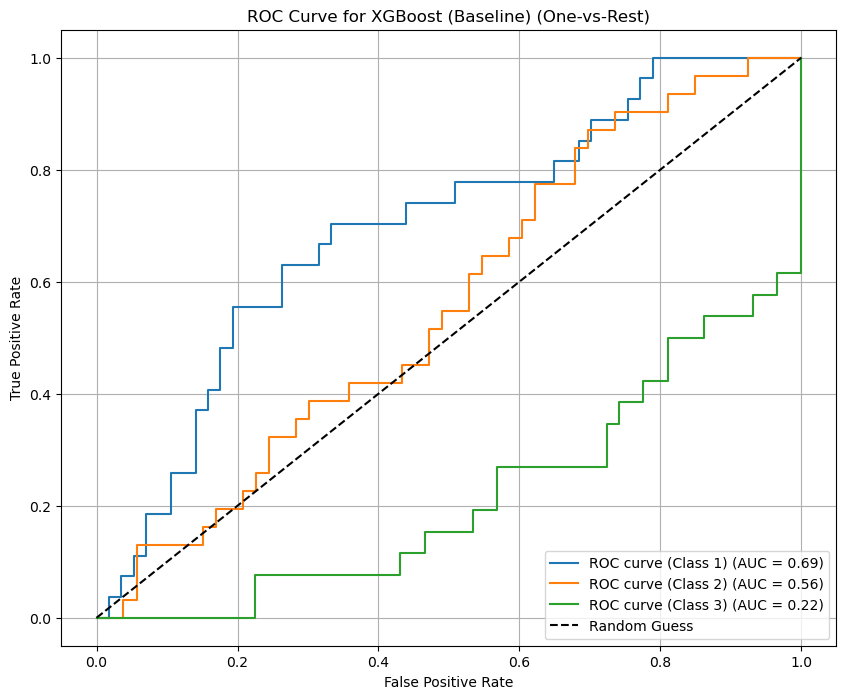

In [69]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
import numpy as np

# The best_model_object and best_model_name are available from previous cell execution.
# Directly use best_model_object as the best_model for ROC-AUC plotting.
best_model = best_model_object

# Ensure best_model is not None before proceeding
if best_model is None:
    raise ValueError("Could not retrieve the best model. Please check best_model_object.")

print(f"--- ROC and AUC for: {best_model_name} ---")

# Determine the correct y_test to use (0-indexed for XGBoost, original y_test for others)
# This was already determined in the previous cell's detailed evaluation
# We need to use `y_test_xgb` if the best model is an XGBoost model, otherwise `y_test`.
if 'XGBoost' in best_model_name:
    y_true_for_roc = y_test_xgb
else:
    y_true_for_roc = y_test

try:
    # Check if the model has predict_proba method
    # For Pipelines, predict_proba is usually available if the final estimator has it
    if hasattr(best_model, 'predict_proba'):
        y_pred_proba = best_model.predict_proba(X_test)

        # Get the unique classes from the actual target variable for correct binarization
        unique_classes = sorted(y_true_for_roc.unique())

        # Binarize the true labels for multi-class ROC (one-vs-rest strategy)
        lb = LabelBinarizer()
        y_test_binarized = lb.fit_transform(y_true_for_roc)

        # If there are only two classes, LabelBinarizer returns a 1D array, make it 2D for consistency
        if y_test_binarized.ndim == 1:
            # For binary case, y_test_binarized is for the positive class
            # We need to construct the 'negative' class probabilities for roc_curve
            y_test_binarized = np.hstack([1 - y_test_binarized.reshape(-1, 1), y_test_binarized.reshape(-1, 1)])

        plt.figure(figsize=(10, 8))
        for i, class_label in enumerate(lb.classes_):
            # Calculate ROC curve for each class (one-vs-rest)
            fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'ROC curve (Class {int(class_label)}) (AUC = {roc_auc:.2f})')

        plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve for {best_model_name} (One-vs-Rest)')
        plt.legend(loc='lower right')
        plt.grid(True)
        plt.show()

    else:
        print(f"Model '{best_model_name}' does not have 'predict_proba' method or it is not enabled.")
        # Specific check for SVM in a pipeline or direct SVC model
        is_svm = False
        if isinstance(best_model, Pipeline):
            if 'svm' in best_model.named_steps and isinstance(best_model.named_steps['svm'], SVC):
                is_svm = True
                if not best_model.named_steps['svm'].probability:
                    print("The SVM model was not initialized with 'probability=True'.")
                    print("ROC-AUC curves require probability estimates, which are not available for this SVM configuration.")
                    print("To enable ROC-AUC for SVM, re-run the GridSearchCV for SVM with `probability=True` in the SVC estimator.")
        elif isinstance(best_model, SVC):
            is_svm = True
            if not best_model.probability:
                print("The SVM model was not initialized with 'probability=True'.")
                print("ROC-AUC curves require probability estimates, which are not available for this SVM configuration.")
                print("To enable ROC-AUC for SVM, re-run the GridSearchCV for SVM with `probability=True` in the SVC estimator.")

        if not is_svm:
            print("This model type might not inherently support `predict_proba` without specific configuration.")

except Exception as e:
    print(f"An error occurred while calculating or plotting ROC/AUC: {e}")
    print("Please ensure the 'best_model' is correctly defined and supports 'predict_proba' or check for specific model requirements (e.g., probability=True for SVC).")


downloading the best_model_object

In [70]:
import pickle

# Define the filename
filename = 'best_model_stage.pkl'

# Save the best_model_object to a .pkl file
with open(filename, 'wb') as file:
    pickle.dump(best_model_object, file)

print(f"The best model object has been saved to {filename}")

The best model object has been saved to best_model_stage.pkl


In [72]:
import joblib
from sklearn.metrics import accuracy_score

# Load the saved model
model = joblib.load("best_model_stage.pkl")

# Predict on your test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)


Model Accuracy: 0.23809523809523808
